In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [ ]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.KX713X_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.KX713X_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [ ]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [ ]:
BUFFER_SIZE = 1000

shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)

train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [ ]:
BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)

validation_data = validation_data.batch(num_validation_samples)

test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [ ]:
from tensorflow.python.training.saver import metrics
input_size = 784 # bo 28*28 pikselki
output_size = 10 #ilosc cyfr

hidden_layer_size= 50

model = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(28,28,1)),

    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),

    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose = 1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8863 - loss: 0.4058 - val_accuracy: 0.9392 - val_loss: 0.2058
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9501 - loss: 0.1735 - val_accuracy: 0.9510 - val_loss: 0.1539
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9623 - loss: 0.1302 - val_accuracy: 0.9592 - val_loss: 0.1348
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9685 - loss: 0.1065 - val_accuracy: 0.9600 - val_loss: 0.1270
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9731 - loss: 0.0913 - val_accuracy: 0.9643 - val_loss: 0.1140
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9774 - loss: 0.0777 - val_accuracy: 0.9647 - val_loss: 0.1166
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9792 - loss: 0.0695 - val_accuracy: 0.9655 - val_loss: 0.1094
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9819 - loss: 0.0595 - val_accuracy: 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Tesst loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9690 - loss: 0.1114
Tesst loss: 0.11. Test accuracy: 96.90%


In [ ]:
def sprawdz_wlasny_obrazek(nazwa_pliku, wytrenowany_model):
    img = cv2.imread(nazwa_pliku, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"BŁĄD: Nie znaleziono pliku '{nazwa_pliku}'. Upewnij się, że wgrałeś go do Colaba!")
        return

    img_resized = cv2.resize(img, (28, 28))
    _, img_threshold = cv2.threshold(img_resized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    img_normalized = img_threshold / 255.0
    img_reshaped = img_normalized.reshape(1, 28, 28, 1)
    predictions = wytrenowany_model.predict(img_reshaped)

    predicted_digit = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    print("\n" + "="*45)
    print(f" MODEL PRZEWIDZIAŁ CYFRĘ: {predicted_digit}")
    print(f" PEWNOŚĆ MODELU: {confidence:.2f}%")
    print("="*45 + "\n")

    plt.figure(figsize=(4, 4))
    plt.imshow(img_threshold, cmap='gray')
    plt.title(f"Rozpoznano: {predicted_digit} ({confidence:.1f}%)", fontsize=14)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 8
 PEWNOŚĆ MODELU: 99.70%



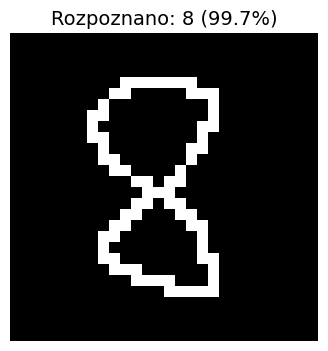

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 3
 PEWNOŚĆ MODELU: 94.25%



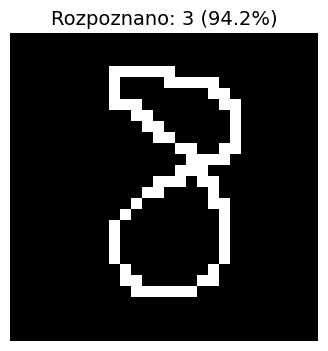

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 8
 PEWNOŚĆ MODELU: 99.74%



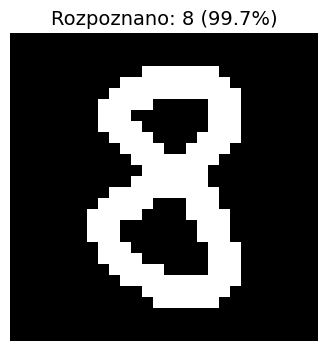

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 3
 PEWNOŚĆ MODELU: 99.96%



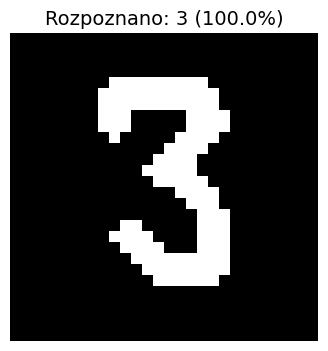

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 3
 PEWNOŚĆ MODELU: 99.93%



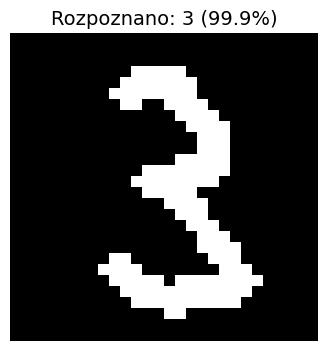

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 3
 PEWNOŚĆ MODELU: 96.16%



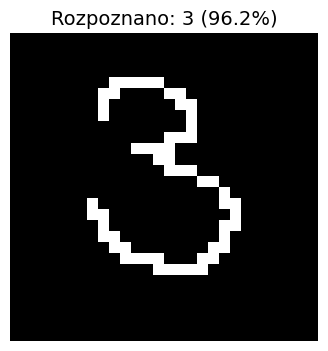

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 2
 PEWNOŚĆ MODELU: 51.68%



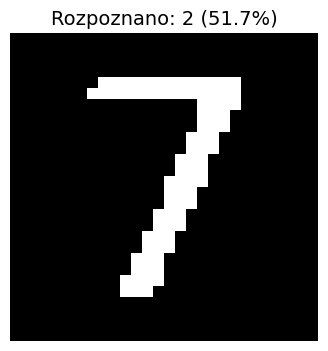

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 7
 PEWNOŚĆ MODELU: 97.90%



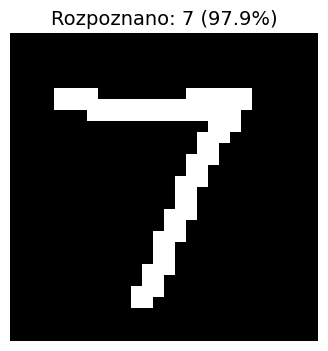

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 1
 PEWNOŚĆ MODELU: 98.01%



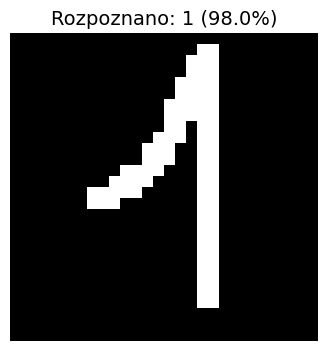

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

 MODEL PRZEWIDZIAŁ CYFRĘ: 1
 PEWNOŚĆ MODELU: 99.06%



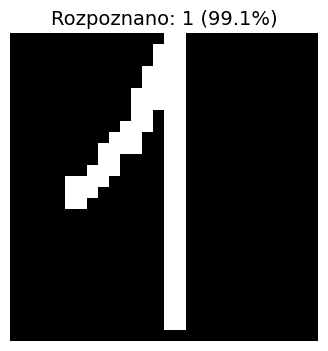

In [ ]:
sprawdz_wlasny_obrazek('8a.png', model)
sprawdz_wlasny_obrazek('8b.png', model)
sprawdz_wlasny_obrazek('8c.png', model)
sprawdz_wlasny_obrazek('3a.png', model)
sprawdz_wlasny_obrazek('3b.png', model)
sprawdz_wlasny_obrazek('3c.png', model)
sprawdz_wlasny_obrazek('7a.png', model)
sprawdz_wlasny_obrazek('7b.png', model)
sprawdz_wlasny_obrazek('1a.png', model)
sprawdz_wlasny_obrazek('1b.png', model)